In [28]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import optuna

In [29]:
df = pd.read_csv("Heart_Disease_Prediction.csv")
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [30]:
df["Heart Disease"] = df["Heart Disease"].map({ "Presence":1, "Absence":0})

In [31]:
X = df.drop("Heart Disease", axis=1)

y = df["Heart Disease"]
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

baseline = DecisionTreeClassifier(random_state=42)
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, baseline_pred))

Baseline Accuracy: 0.7962962962962963


In [32]:
def objective(trial):
    max_depth = trial.suggest_int("max_depth",1,20)
    model = DecisionTreeClassifier(  max_depth=max_depth,  random_state=42)
    score = cross_val_score( model, X_train, y_train, cv=5, scoring="accuracy").mean()
    return score

In [33]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

[I 2026-07-25 13:42:59,815] A new study created in memory with name: no-name-1b6fb569-8f6b-48e2-8900-66c1de85ab5b
[I 2026-07-25 13:42:59,870] Trial 0 finished with value: 0.7497885835095137 and parameters: {'max_depth': 7}. Best is trial 0 with value: 0.7497885835095137.
[I 2026-07-25 13:42:59,917] Trial 1 finished with value: 0.7497885835095137 and parameters: {'max_depth': 8}. Best is trial 0 with value: 0.7497885835095137.
[I 2026-07-25 13:42:59,963] Trial 2 finished with value: 0.7637420718816068 and parameters: {'max_depth': 4}. Best is trial 2 with value: 0.7637420718816068.
[I 2026-07-25 13:43:00,005] Trial 3 finished with value: 0.7544397463002113 and parameters: {'max_depth': 20}. Best is trial 2 with value: 0.7637420718816068.
[I 2026-07-25 13:43:00,061] Trial 4 finished with value: 0.7544397463002113 and parameters: {'max_depth': 10}. Best is trial 2 with value: 0.7637420718816068.
[I 2026-07-25 13:43:00,100] Trial 5 finished with value: 0.7544397463002113 and parameters: {'

In [34]:
print("Best max_depth:", study.best_params["max_depth"])
print("Best CV Accuracy:", study.best_value)

Best max_depth: 3
Best CV Accuracy: 0.7684989429175475


In [35]:
best_depth = study.best_params["max_depth"]
best_tree = DecisionTreeClassifier( max_depth=best_depth, random_state=42)
best_tree.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [36]:
pred = best_tree.predict(X_test)

print(classification_report(y_test, pred))
print("Accuracy:", accuracy_score(y_test, pred))

              precision    recall  f1-score   support

           0       0.92      0.77      0.84        30
           1       0.76      0.92      0.83        24

    accuracy                           0.83        54
   macro avg       0.84      0.84      0.83        54
weighted avg       0.85      0.83      0.83        54

Accuracy: 0.8333333333333334


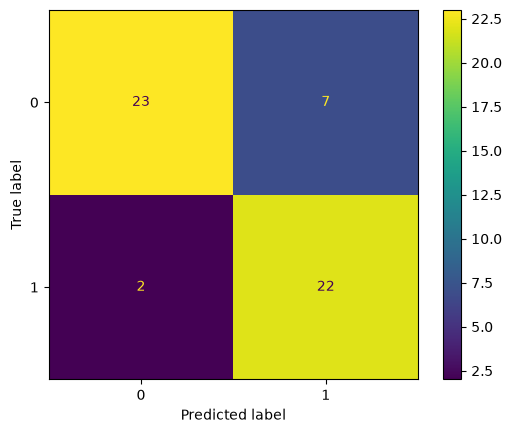

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(best_tree,X_test,y_test)
plt.show()

In [38]:
comparison = pd.DataFrame({"Model": [
        "Default Decision Tree",
        "Optuna Decision Tree"
    ],
    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, pred)
    ]
})

comparison

,Model,Accuracy
0,Default Decision Tree,0.796296
1,Optuna Decision Tree,0.833333
